# Chombo (PLUTO-AMR): First Inspection

Chombo is not a simulation code. It is an adaptive-mesh-refinement framework that supplies the
grid hierarchy and the HDF5 output several codes are built on, PLUTO's AMR mode among them. Mera
reads that layout, so a code writing Chombo output is readable whether or not Mera knows the code
itself.

The run here is a collapsing isothermal sphere: a dense core, refined where the gas is densest.

!!! note "You can download this snapshot"
    It is the `IsothermalSphere` sample from the yt project, so everything below is reproducible:

    ```bash
    curl -O https://yt-project.org/data/IsothermalSphere.tar.gz
    tar xzf IsothermalSphere.tar.gz
    ```


## 1. One call to see everything

`quicklook` reads the gas, projects it along each axis, builds a density-temperature diagram and
prints a summary. Unlike many formats, this one already stores its data in CGS, so there are no
unit constants to supply.


In [1]:
using Mera, CairoMakie

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/CHOMBO/chombo_3d/IsothermalSphere"
ql = quicklook(0; path=path);



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v2.0.0-DEV | Julia 1.12.7 | 8 threads

[Mera]: quicklook output 0, reading gas: 2026-09-15T19:34:31.787



   1 CPU file(s), levels 5-7 of 7  (full resolution)
   projecting 3 gas map(s) [z, x, y] and the phase diagram from 646248 cells


┌─ Mera quicklook ── output 0 (CHOMBO) ───────────────


│ box        : 0.0001205 kpc      levels 5–7  (finest 0.0009413 pc)
│ grid       : ndim 3 · ncpu 1 · nvarh 6
│ time       : 0.0 Myr  (non-cosmological)
│ read       : 646248 cells  (full resolution)
│ gas mass   : 1.219 M⊙
│ nH range   : 11240.0 … 1.035e7 cm⁻³
│ T  range   : 34170.0 … 34170.0 K
└─ 7.29 s ──────────────────────────────────
[Mera]: quicklook output 0 finished: 2026-09-15T19:34:37.811



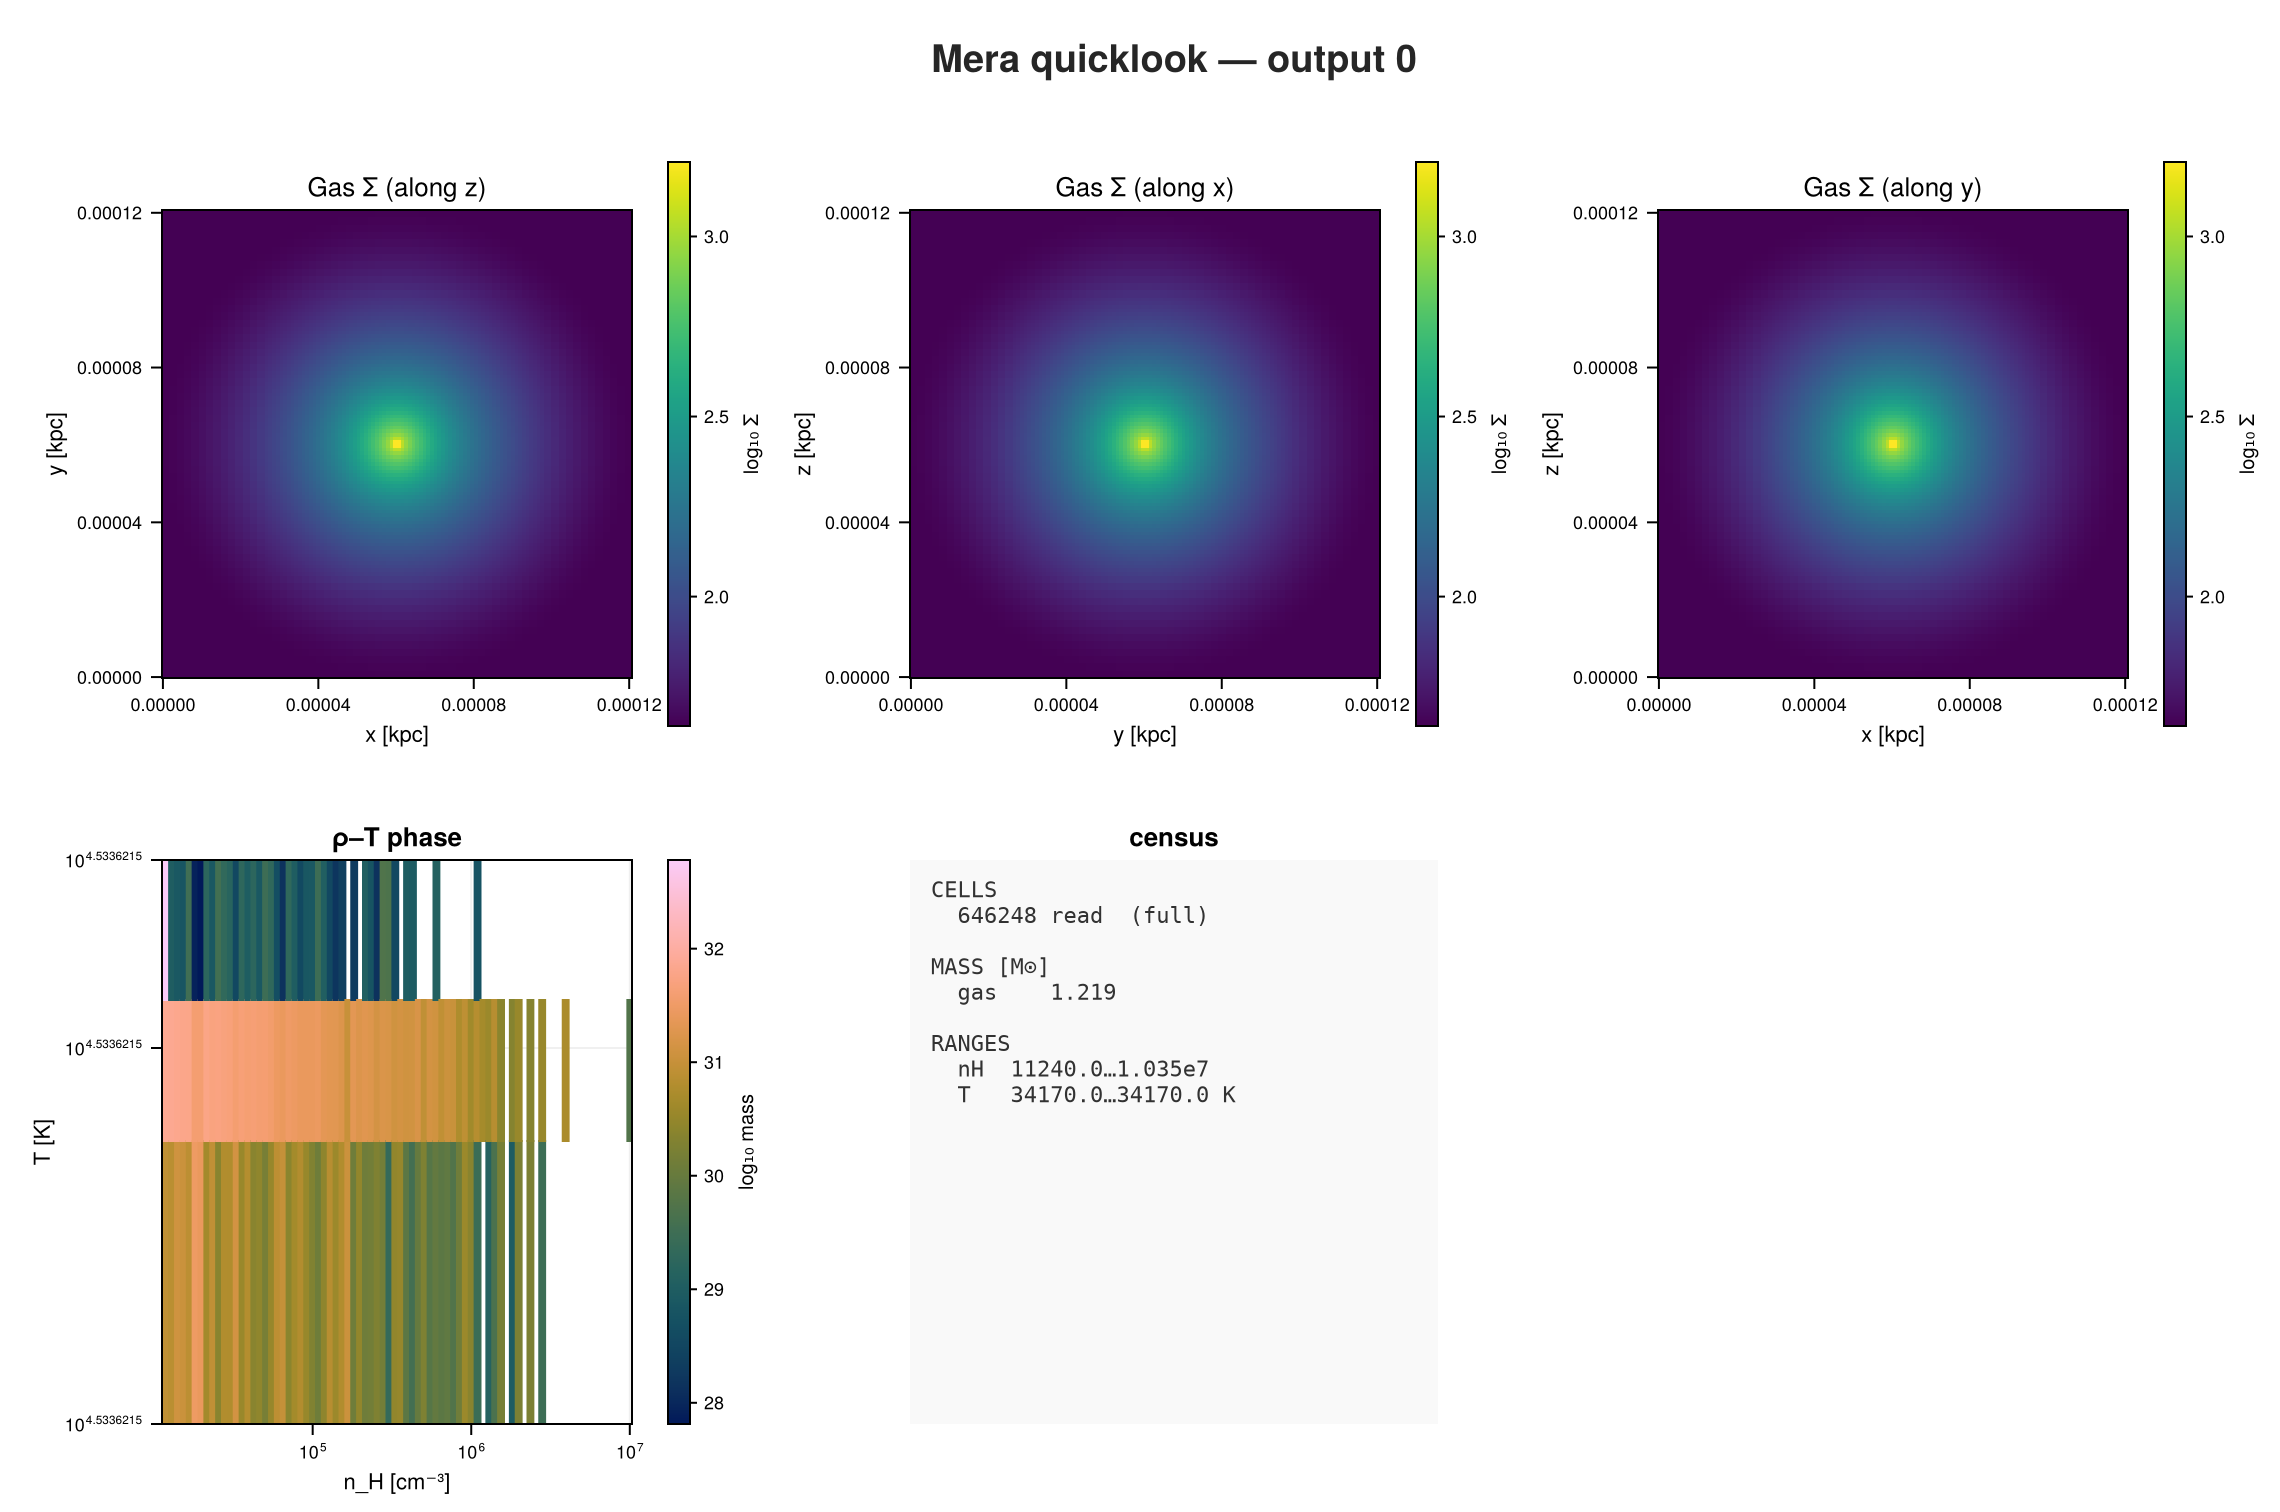

In [2]:
quicklookplot(ql)


A dense core in the middle of a small box. The numbers are physical straight away: about
1.2 solar masses inside 0.12 parsec.


## 2. The details: `getinfo`


In [3]:
info = getinfo(0, path);


Code: CHOMBO  (PLUTO-AMR / Orion format)
output: 0  time: 0.0 [code units]
AMR levels 5–7  boxlen = 3.71787206996e17
components: (density, X-momentum, Y-momentum, Z-momentum, X-magnfield, Y-magnfield, Z-magnfield, energy-density, gravitational-potential)
variables: (rho, vx, vy, vz, p, gpot)
-------------------------------------------------------
[Mera]: composition not recorded by this format; using X = 0.76, mu = 1.32 (RAMSES convention) for :nH and :T. Change with setcomposition!(info; X_frac=…, mu=…).


In [4]:
info.simcode, info.levelmin, info.levelmax, info.variable_list


("CHOMBO", 5, 7, [:rho, :vx, :vy, :vz, :p, :gpot])

Note the level range. This is a **refined** grid, not a uniform one, so cells exist at more than
one resolution. The box itself is small:


In [5]:
info.boxlen * info.scale.pc        # box size in parsec


0.12048802805955357

## 3. What else could be loaded?


In [6]:
capabilities(info)


2-element Vector{Symbol}:
 :info
 :hydro

Chombo files carry gas. This particular run also stored the gravitational potential, which shows
up as an ordinary variable rather than a separate data type.


## 4. Load the gas


In [7]:
gas = gethydro(info);


[Mera]: CHOMBO AMR → 646248

 leaf cells, levels 5–7, vars rho, vx, vy, vz, p, gpot


## 5. What the data looks like

One table, one row per cell.


In [8]:
gas.data


Table with 646248 rows, 10 columns:
Columns:
#   colname  type
────────────────────
1   level    Int32
2   cx       Int32
3   cy       Int32
4   cz       Int32
5   rho      Float64
6   vx       Float64
7   vy       Float64
8   vz       Float64
9   p        Float64
10  gpot     Float64

Compared with a uniform grid there is one extra column: **`level`**. Each cell records which
refinement level it belongs to, and its position and size follow from that:

```
cell centre = (c - 0.5) * boxlen / 2^level
cell size   =             boxlen / 2^level
```

So the table holds cells of different sizes side by side, with no resampling onto a common grid.


In [9]:
amroverview(gas)


Counting...


Table with 3 rows, 3 columns:
level  cells   cellsize
─────────────────────────
5      0       1.16184e16
6      207272  5.80918e15
7      438976  2.90459e15

`amroverview` is the quickest way to see the refinement: how many cells sit at each level and
how big they are. Level 5 is the base grid and holds nothing here, because every one of its
cells was refined away. The finer cells are exactly half the size of the coarser ones, and most
of the data sits at the finest level, which is where the collapsing core is.


## 6. Physical quantities

Ask for anything by name, in any unit.


In [10]:
msum(gas, :Msol)                    # total gas mass


1.2192374338591871

In [11]:
extrema(getvar(gas, :rho, :nH))     # hydrogen number density, cm^-3


(11244.756676104671, 1.0351161344590483e7)

`:nH` converts a mass density to a hydrogen number density, which needs the hydrogen **mass
fraction**. No simulation format records it, so Mera starts from the RAMSES value, X = 0.76. If
your run assumes something else, say so once and everything downstream follows:

```julia
setcomposition!(info; X_frac=0.711, mu=0.614)   # for example, PLUTO defaults
```

The temperature here is flat, 25970 K per unit μ in every cell, because this is an *isothermal*
sphere. That is also why the phase diagram above is a single line rather than a cloud: the setup
fixes the temperature, so there is no thermal structure to show.


In [12]:
extrema(getvar(gas, :gpot))         # the stored gravitational potential


(-1.5574393185966113e9, -177954.43640389142)

## 7. A projection

Column density along z. Mera projects the refined cells directly: a cell contributes to the map
over the area it actually covers, so nothing is resampled onto a coarse grid first.


In [13]:
proj = projection(gas, :sd, :g_cm2, direction=:z);
size(proj.maps[:sd])


[Mera]: 2026-09-15T19:34:57.003



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [mpc] :: 120.488 [mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [mpc] :: 120.488 [mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [mpc] :: 120.488 [mpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 128^2
Map size: 128 x 128
Pixel size: 0.941 [mpc]
Simulation min.: 0.941 [mpc]

Available threads: 8
Requested max_threads: 8
Variables: 1 (sd)
Processing mode: Sequential (single thread)


(128, 128)

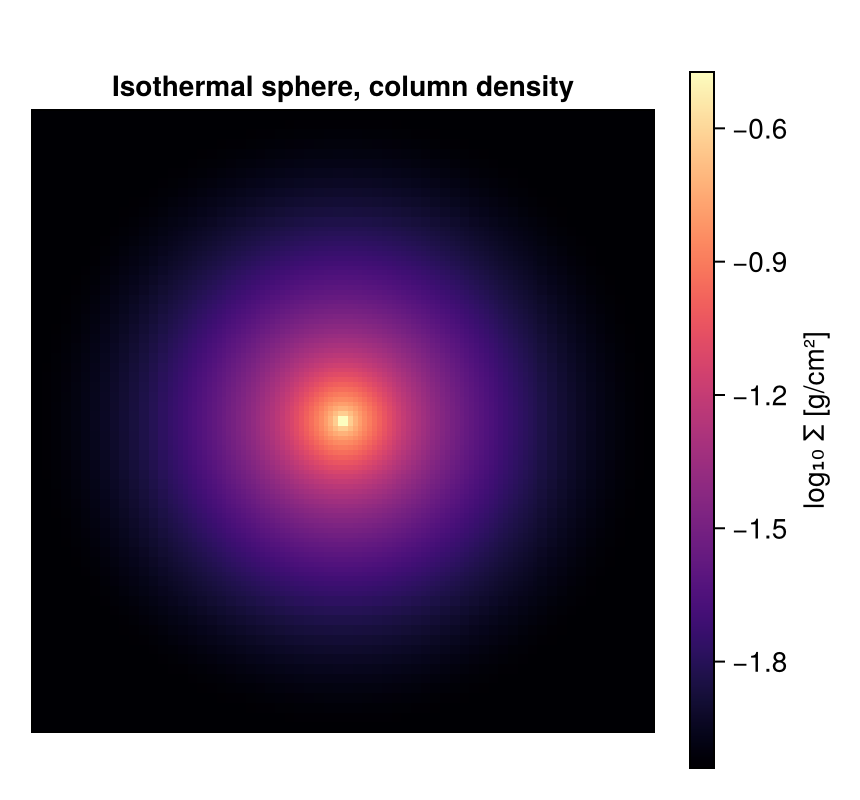

In [14]:
fig = Figure(size=(430, 400))
ax  = Axis(fig[1,1]; title="Isothermal sphere, column density", aspect=DataAspect())
hidedecorations!(ax)
hm = heatmap!(ax, log10.(proj.maps[:sd]'); colormap=:magma)
Colorbar(fig[1,2], hm, label="log₁₀ Σ [g/cm²]")
fig


## Where to go next

The same five calls as on any other code: `quicklook`, `getinfo`, `gethydro`, `getvar`,
`projection`. The only thing that changed is that the cells come at more than one size, and
nothing downstream had to be told.

From here every tutorial on this site applies unchanged: sub-regions, profiles, phase diagrams,
movies and off-axis projections all work on this table.
